In [44]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/crawford/emnist/emnist-letters-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-letters-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-balanced-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-byclass-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-mnist-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-mapping.txt
/kaggle/input/datasets/crawford/emnist/em

In [45]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np


class EMNISTDataset(Dataset):
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path, header=None)
        pixels = df.iloc[:, 1:].values.astype(np.float32)#shape: (N, 784)
        self.images = torch.tensor(pixels / 255.0)#normalizing to [0, 1] 

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        #here we are ReturnIng shape (1, 28, 28) that means 1 channel, 28x28 spatial
        return self.images[idx].reshape(1, 28, 28)


def get_loaders(train_csv, test_csv, batch_size=128, num_workers=2):
    train_dataset = EMNISTDataset(train_csv)
    test_dataset  = EMNISTDataset(test_csv)
    train_loader = DataLoader(train_dataset, batch_size=batch_size,shuffle=True,  num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size,shuffle=False, num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader
    
#here batch size means how many samples we want to process before updating the model parameters. num_workers is the number of subprocesses to use for data loading. If num_workers is greater than 0, the data loading will be done in parallel using subprocesses, which can speed up the data loading process. pin_memory=True means that the data loader will copy tensors into CUDA pinned memory before returning them, which can improve performance when using a GPU.
#here num_workers is set to 2, which means that two subprocesses will be used for data loading. This can help speed up the data loading process, especially if the dataset is large and the data loading is a bottleneck. However, the optimal number of workers can depend on the specific hardware and dataset, so it may require some experimentation to find the best setting.

In [46]:
"""
For ANN (Fully Connected) Autoencoders — 2 variants

Variant 1 — Shallow:  784 → 256 → bottleneck → 256 → 784
Variant 2 — Deep:     784 → 512 → 256 → 128 → bottleneck → 128 → 256 → 512 → 784

Bottleneck size: 32 for Vriant 1
Bottleneck size : 64 for Variant 2
"""

'\nFor ANN (Fully Connected) Autoencoders — 2 variants\n\nVariant 1 — Shallow:  784 → 256 → bottleneck → 256 → 784\nVariant 2 — Deep:     784 → 512 → 256 → 128 → bottleneck → 128 → 256 → 512 → 784\n\nBottleneck size: 32 for Vriant 1\nBottleneck size : 64 for Variant 2\n'

In [47]:

import torch.nn as nn


class ANNAutoencoder_V1(nn.Module):
    def __init__(self, bottleneck_size=32):
        super().__init__()

        # Encoder: Journey to Latent SPace
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, bottleneck_size),
            nn.ReLU(),
        )

        # Decoder: Journey from Latent Space
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),   # here we are taking output in [0,1] to match normalized input
        )

    def forward(self, x):
        # x shape: (batch, 1, 28, 28)
        batch = x.size(0)
        x_flat = x.view(batch, -1)          # flatten → (batch, 784)
        z      = self.encoder(x_flat)        # compress → (batch, bottleneck)
        x_hat  = self.decoder(z)             # reconstruct → (batch, 784)
        return x_hat.view(batch, 1, 28, 28)  # reshape back to image

    def encode(self, x):
        """Returning latent vector, will use for visualisation using pca"""
        batch = x.size(0)
        x_flat = x.view(batch, -1)          
        z = self.encoder(x_flat)
        return z

In [48]:
class ANNAutoencoder_V2(nn.Module):
    def __init__(self, bottleneck_size=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, bottleneck_size),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 784),
            nn.Sigmoid(),
        )

    def forward(self, x):
        batch = x.size(0)
        x_flat = x.view(batch, -1)
        z      = self.encoder(x_flat)
        x_hat  = self.decoder(z)
        return x_hat.view(batch, 1, 28, 28)

    def encode(self, x):
        batch = x.size(0)
        x_flat = x.view(batch, -1)
        z      = self.encoder(x_flat)
        return z



In [49]:
"""
CNN Autoencoders — 2 variants

Variant 1 — Shallow CNN:
  Encoder: Conv(1→16) → Conv(16→32) → flatten → Linear(bottleneck)
  Decoder: Linear → unflatten → ConvTranspose(32→16) → ConvTranspose(16→1)

Variant 2 — Deep CNN:
  Encoder: 4 conv blocks with BatchNorm
  Decoder: 4 deconv blocks 
"""

'\nCNN Autoencoders — 2 variants\n\nVariant 1 — Shallow CNN:\n  Encoder: Conv(1→16) → Conv(16→32) → flatten → Linear(bottleneck)\n  Decoder: Linear → unflatten → ConvTranspose(32→16) → ConvTranspose(16→1)\n\nVariant 2 — Deep CNN:\n  Encoder: 4 conv blocks with BatchNorm\n  Decoder: 4 deconv blocks \n'

In [50]:
import torch
import torch.nn as nn


class CNNAutoencoder_V1(nn.Module):
    def __init__(self, bottleneck_size=32):
        super().__init__()

        # After 2x MaxPool(2): 28 → 14 → 7. So flattened = 7*7*32 = 1568
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (B,16,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (B,16,14,14)

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # (B,32,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (B,32,7,7)
        )
        self.encoder_fc = nn.Linear(32 * 7 * 7, bottleneck_size)

        self.decoder_fc = nn.Linear(bottleneck_size, 32 * 7 * 7)
        self.decoder_conv = nn.Sequential(
            # ConvTranspose2d is the "reverse convolution" — upsamples
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2), # (B,16,14,14)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),  # (B,1,28,28)
            nn.Sigmoid(),
        )

    def encode(self, x):
        x = self.encoder_conv(x)                 # (B,32,7,7)
        x = x.view(x.size(0), -1)               # flatten → (B,1568)
        z = self.encoder_fc(x)                   # → (B, bottleneck)
        return z

    def decode(self, z):
        x = self.decoder_fc(z)                   # (B,1568)
        x = x.view(x.size(0), 32, 7, 7)         # unflatten
        x = self.decoder_conv(x)                 # (B,1,28,28)
        return x

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)



In [51]:
class CNNAutoencoder_V2(nn.Module):
    def __init__(self, bottleneck_size=64):
        super().__init__()

        # stride=2 Conv halves spatial dims (like MaxPool but learnable)
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),   # (B,32,14,14)
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # (B,64,7,7)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # (B,128,4,4)
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),# (B,256,2,2)
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        self.encoder_fc = nn.Linear(256 * 2 * 2, bottleneck_size)

        self.decoder_fc = nn.Linear(bottleneck_size, 256 * 2 * 2)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1), # (B,128,4,4)
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),  # (B,64,7,7)
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),   # (B,32,14,14)
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),    # (B,1,28,28)
            nn.Sigmoid(),
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1)
        return self.encoder_fc(x)

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(x.size(0), 256, 2, 2)
        return self.decoder_conv(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)


In [52]:
"""
Visualisation utilities:
  1. plot_losses() — training vs validation loss curves for all models
  2. plot_reconstructions() — original vs reconstructed image grid
  3. plot_latent_space() — 2D PCA projection of latent vectors (coloured by class)
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_losses(histories: dict, save_path="results/loss_curves.png"):
    n = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)

    for ax, (name, h) in zip(axes[0], histories.items()):
        epochs = range(1, len(h["train_loss"]) + 1)
        ax.plot(epochs, h["train_loss"], label="Train", linewidth=2)
        ax.plot(epochs, h["val_loss"],   label="Val",   linewidth=2, linestyle="--")
        ax.set_title(name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("Training vs Validation Loss — All Models", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {save_path}")


def plot_reconstructions(model, data_loader, device, model_name,
                         n=10, save_path=None):
    model.eval()
    batch = next(iter(data_loader))[:n].to(device)

    with torch.no_grad():
        reconstructed = model(batch)

    originals = batch.cpu().squeeze(1).numpy()        # (n, 28, 28)
    recons    = reconstructed.cpu().squeeze(1).numpy()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3))
    for i in range(n):
        axes[0, i].imshow(originals[i], cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[1, i].imshow(recons[i],    cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")

    axes[0, 0].set_title("Original", fontsize=9, loc="left")
    axes[1, 0].set_title("Reconstructed", fontsize=9, loc="left")
    plt.suptitle(model_name, fontsize=11)
    plt.tight_layout()

    save_path = save_path or f"results/recon_{model_name.replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {save_path}")


def plot_latent_space(model, data_loader, device, model_name,
                      n_samples=2000, save_path=None):
    model.eval()
    all_z, all_labels = [], []

    for i, batch in enumerate(data_loader):
        # batch is just images (no labels in our Dataset class)
        # we use the batch index as a proxy — for real labels, pass a labelled loader
        imgs = batch.to(device)
        with torch.no_grad():
            z = model.encode(imgs)
        all_z.append(z.cpu().numpy())
        if len(all_z) * imgs.size(0) >= n_samples:
            break

    Z = np.concatenate(all_z, axis=0)[:n_samples]

    # Reduce to 2D for visualisation
    if Z.shape[1] > 2:
        pca = PCA(n_components=2)
        Z2d = pca.fit_transform(Z)
        explained = pca.explained_variance_ratio_.sum() * 100
        xlabel = f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
        ylabel = f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
    else:
        Z2d   = Z
        explained = 100.0
        xlabel, ylabel = "z[0]", "z[1]"

    fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(Z2d[:, 0], Z2d[:, 1], s=4, alpha=0.4, c=range(len(Z2d)),
                         cmap="tab20", linewidths=0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Latent Space — {model_name}\n(PCA, {explained:.1f}% variance)")
    plt.tight_layout()

    save_path = save_path or f"results/latent_{model_name.replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {save_path}")

In [53]:
#Training function snippet
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time


def train_model(model, train_loader, val_loader, model_name,
                epochs=25, lr=7e-4, device="cuda"):
    model = model.to(device)
    criterion = nn.MSELoss()         # reconstruction loss: ||x - x_hat||^2
    optimizer = Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history = {"train_loss": [], "val_loss": []}

    print(f"\n{'='*55}")
    print(f"  Training: {model_name}")
    print(f"  Device: {device} | Epochs: {epochs} | LR: {lr}")
    print(f"{'='*55}")

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        model.train()
        train_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad()
            reconstructed = model(batch)          # forward pass
            loss = criterion(reconstructed, batch) # compare output vs input
            loss.backward()                        # backprop
            optimizer.step()                       # update weights

            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                reconstructed = model(batch)
                val_loss += criterion(reconstructed, batch).item()

        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        elapsed = time.time() - t0
        print(f"  Epoch [{epoch:02d}/{epochs}] "
              f"train: {train_loss:.5f} | val: {val_loss:.5f} | {elapsed:.1f}s")

    print(f"  Done. Best val loss: {min(history['val_loss']):.5f}\n")
    return history


def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"  Saved model → {path}")


def load_model(model, path, device="cuda"):
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


Device: cuda

  Training: ANN V1 - Shallow (b=32)
  Device: cuda | Epochs: 50 | LR: 0.0007
  Epoch [01/50] train: 0.03056 | val: 0.01792 | 6.3s
  Epoch [02/50] train: 0.01617 | val: 0.01511 | 6.3s
  Epoch [03/50] train: 0.01408 | val: 0.01351 | 6.3s
  Epoch [04/50] train: 0.01293 | val: 0.01265 | 6.3s
  Epoch [05/50] train: 0.01219 | val: 0.01206 | 6.3s
  Epoch [06/50] train: 0.01169 | val: 0.01166 | 6.3s
  Epoch [07/50] train: 0.01132 | val: 0.01134 | 6.3s
  Epoch [08/50] train: 0.01103 | val: 0.01109 | 6.3s
  Epoch [09/50] train: 0.01081 | val: 0.01092 | 6.3s
  Epoch [10/50] train: 0.01062 | val: 0.01070 | 6.2s
  Epoch [11/50] train: 0.01047 | val: 0.01062 | 6.2s
  Epoch [12/50] train: 0.01032 | val: 0.01045 | 6.3s
  Epoch [13/50] train: 0.01020 | val: 0.01040 | 6.2s
  Epoch [14/50] train: 0.01009 | val: 0.01030 | 6.3s
  Epoch [15/50] train: 0.00999 | val: 0.01017 | 6.2s
  Epoch [16/50] train: 0.00991 | val: 0.01013 | 6.2s
  Epoch [17/50] train: 0.00984 | val: 0.01005 | 6.4s
  Epoch 

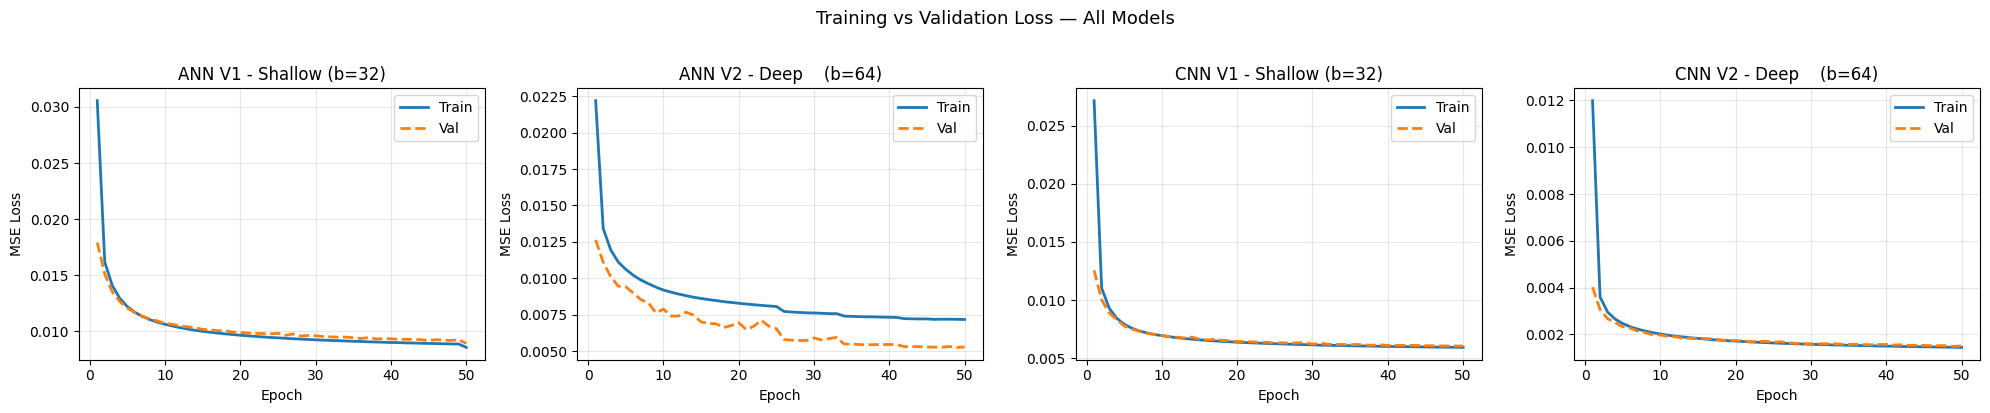

  Saved → results/loss_curves.png


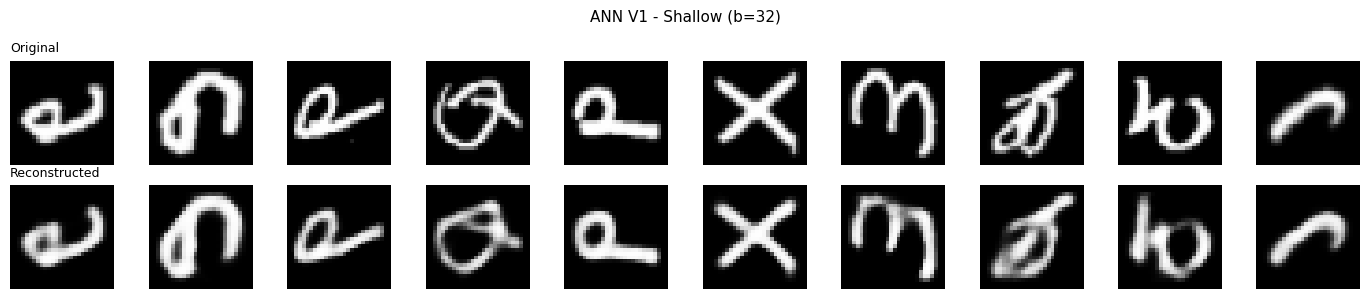

  Saved → results/recon_ANN_V1_-_Shallow_(b=32).png


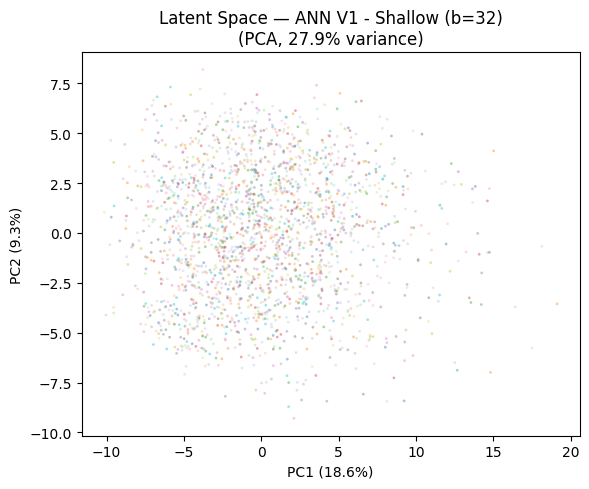

  Saved → results/latent_ANN_V1_-_Shallow_(b=32).png


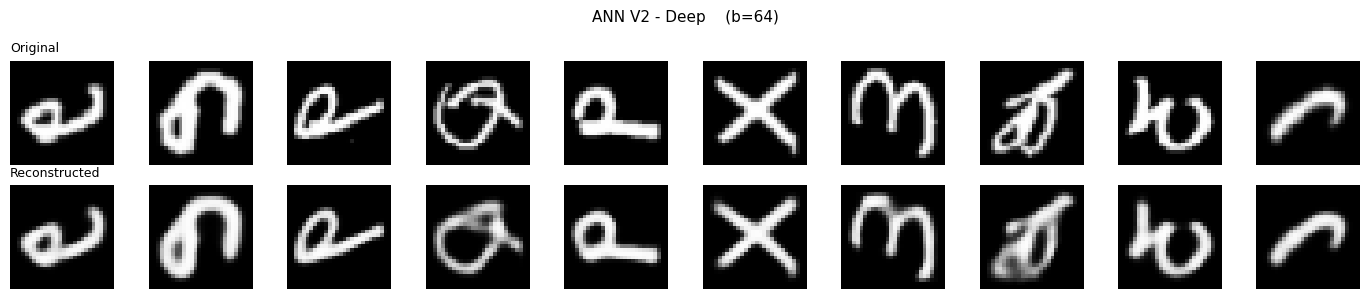

  Saved → results/recon_ANN_V2_-_Deep____(b=64).png


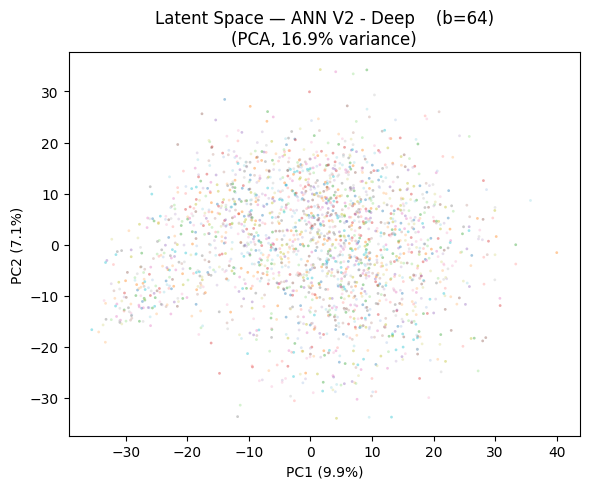

  Saved → results/latent_ANN_V2_-_Deep____(b=64).png


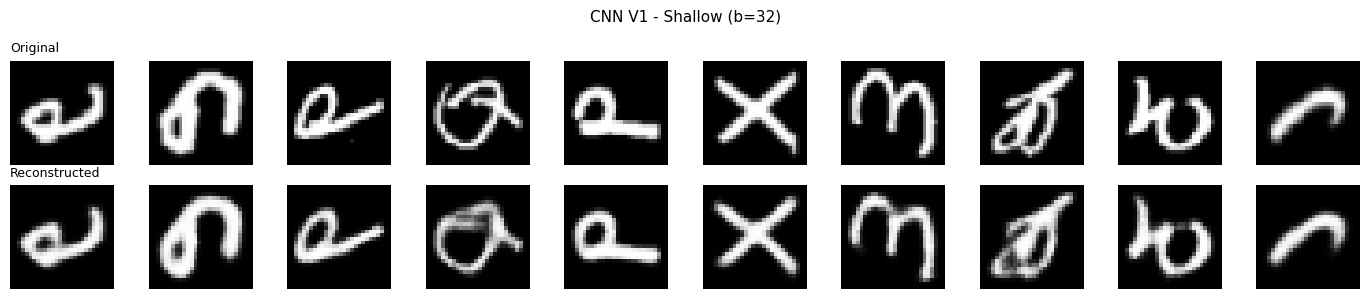

  Saved → results/recon_CNN_V1_-_Shallow_(b=32).png


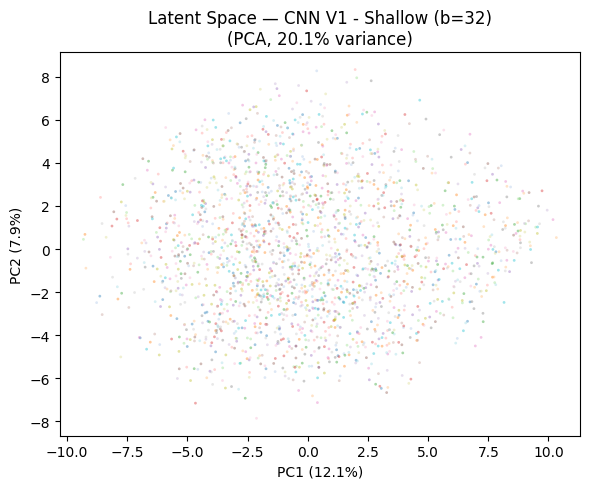

  Saved → results/latent_CNN_V1_-_Shallow_(b=32).png


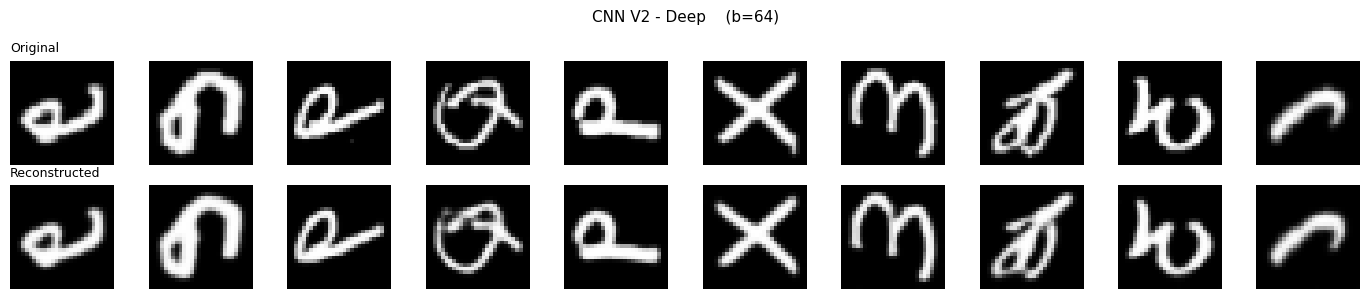

  Saved → results/recon_CNN_V2_-_Deep____(b=64).png


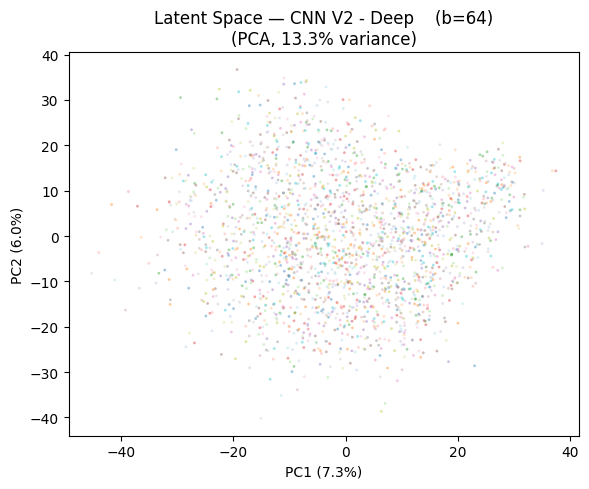

  Saved → results/latent_CNN_V2_-_Deep____(b=64).png

All done. Check the results/ folder.


In [54]:
import torch
import os

os.makedirs("results", exist_ok=True)

TRAIN_CSV= "/kaggle/input/datasets/crawford/emnist/emnist-balanced-train.csv"
TEST_CSV= "/kaggle/input/datasets/crawford/emnist/emnist-balanced-test.csv"
BATCH_SIZE= 64
EPOCHS= 50
DEVICE= "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")

train_loader, val_loader = get_loaders(TRAIN_CSV, TEST_CSV, batch_size=BATCH_SIZE)

models_to_train = [
    (ANNAutoencoder_V1(bottleneck_size=32), "ANN V1 - Shallow (b=32)", "ann_v1_b32.pt"),
    (ANNAutoencoder_V2(bottleneck_size=64), "ANN V2 - Deep    (b=64)", "ann_v2_b64.pt"),
    (CNNAutoencoder_V1(bottleneck_size=32), "CNN V1 - Shallow (b=32)", "cnn_v1_b32.pt"),
    (CNNAutoencoder_V2(bottleneck_size=64), "CNN V2 - Deep    (b=64)", "cnn_v2_b64.pt"),
]

histories = {}
trained_models = {}

for model, name, filename in models_to_train:
    history = train_model(model, train_loader, val_loader,
                          model_name=name, epochs=EPOCHS, device=DEVICE)
    save_model(model, f"results/{filename}")
    histories[name] = history
    trained_models[name] = model

plot_losses(histories, save_path="results/loss_curves.png")

#Visualising reconstructions & latent space for each model 
for name, model in trained_models.items():
    model = model.to(DEVICE)
    plot_reconstructions(model, val_loader, DEVICE, model_name=name)
    plot_latent_space(model, val_loader, DEVICE, model_name=name)

print("\nAll done. Check the results/ folder.")
